In [72]:
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

## Загрузка и первичный анализ данных

In [13]:
data = pd.read_csv('WineQT.csv', sep=",")

In [14]:
data.shape

(1143, 13)

In [15]:
data.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [16]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [17]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Кодирование категориальных признаков

In [18]:
data_new = data.drop('Id', axis=1)

## Обучающая и тестовая выборки

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

In [35]:
# Целевая переменная
data['target'] = (data['quality'] >= 6).astype(int)
X = data.drop(['quality', 'target'], axis=1)
Y = data['target']

In [37]:
# Разделение на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [38]:
# Масштабирование признаков для SVR и LinearRegression (рекомендуется)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Логистическая регрессия

In [41]:
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_sc, Y_train)

Y_pred_lr  = lr.predict(X_test_sc)
Y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

acc_lr = accuracy_score(Y_test, Y_pred_lr)
f1_lr  = f1_score(Y_test, Y_pred_lr)
roc_lr = roc_auc_score(Y_test, Y_prob_lr)

print('=== Логистическая регрессия ===')
print(f'Accuracy : {acc_lr:.4f}')
print(f'F1-score : {f1_lr:.4f}')
print(f'ROC-AUC  : {roc_lr:.4f}')
print()
print(classification_report(Y_test, Y_pred_lr, target_names=['Плохое', 'Хорошее']))

=== Логистическая регрессия ===
Accuracy : 0.7686
F1-score : 0.7905
ROC-AUC  : 0.8211

              precision    recall  f1-score   support

      Плохое       0.74      0.75      0.74       102
     Хорошее       0.79      0.79      0.79       127

    accuracy                           0.77       229
   macro avg       0.77      0.77      0.77       229
weighted avg       0.77      0.77      0.77       229



### SVM (метод опорных векторов)

In [46]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_sc, Y_train)

Y_pred_svm = svm.predict(X_test_sc)
Y_prob_svm = svm.predict_proba(X_test_sc)[:, 1]

acc_svm = accuracy_score(Y_test, Y_pred_svm)
f1_svm  = f1_score(Y_test, Y_pred_svm)
roc_svm = roc_auc_score(Y_test, Y_prob_svm)

print('=== SVM ===')
print(f'Accuracy : {acc_svm:.4f}')
print(f'F1-score : {f1_svm:.4f}')
print(f'ROC-AUC  : {roc_svm:.4f}')
print()
print(classification_report(Y_test, Y_pred_svm, target_names=['Плохое', 'Хорошее']))

=== SVM ===
Accuracy : 0.7686
F1-score : 0.7922
ROC-AUC  : 0.8777

              precision    recall  f1-score   support

      Плохое       0.74      0.74      0.74       102
     Хорошее       0.79      0.80      0.79       127

    accuracy                           0.77       229
   macro avg       0.77      0.77      0.77       229
weighted avg       0.77      0.77      0.77       229



### Дерево решений

In [49]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
dt.fit(X_train, Y_train)   # деревья не требуют масштабирования

Y_pred_dt = dt.predict(X_test)
Y_prob_dt = dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(Y_test, Y_pred_dt)
f1_dt  = f1_score(Y_test, Y_pred_dt)
roc_dt = roc_auc_score(Y_test, Y_prob_dt)

print('=== Дерево решений (max_depth=5) ===')
print(f'Accuracy : {acc_dt:.4f}')
print(f'F1-score : {f1_dt:.4f}')
print(f'ROC-AUC  : {roc_dt:.4f}')
print()
print(classification_report(Y_test, Y_pred_dt, target_names=['Плохое', 'Хорошее']))

=== Дерево решений (max_depth=5) ===
Accuracy : 0.7424
F1-score : 0.7649
ROC-AUC  : 0.7822

              precision    recall  f1-score   support

      Плохое       0.70      0.73      0.71       102
     Хорошее       0.77      0.76      0.76       127

    accuracy                           0.74       229
   macro avg       0.74      0.74      0.74       229
weighted avg       0.74      0.74      0.74       229



### Сравнение качества моделей

In [50]:
results = pd.DataFrame({
    'Модель'   : ['Логистическая регрессия', 'SVM', 'Дерево решений'],
    'Accuracy' : [acc_lr, acc_svm, acc_dt],
    'F1-score' : [f1_lr,  f1_svm,  f1_dt],
    'ROC-AUC'  : [roc_lr, roc_svm, roc_dt],
})
results = results.set_index('Модель')
results.style.highlight_max(axis=0, color='#c7e9c0').format('{:.4f}')

,Accuracy,F1-score,ROC-AUC
Модель,,,
Логистическая регрессия,0.7686,0.7905,0.8211
SVM,0.7686,0.7922,0.8777
Дерево решений,0.7424,0.7649,0.7822


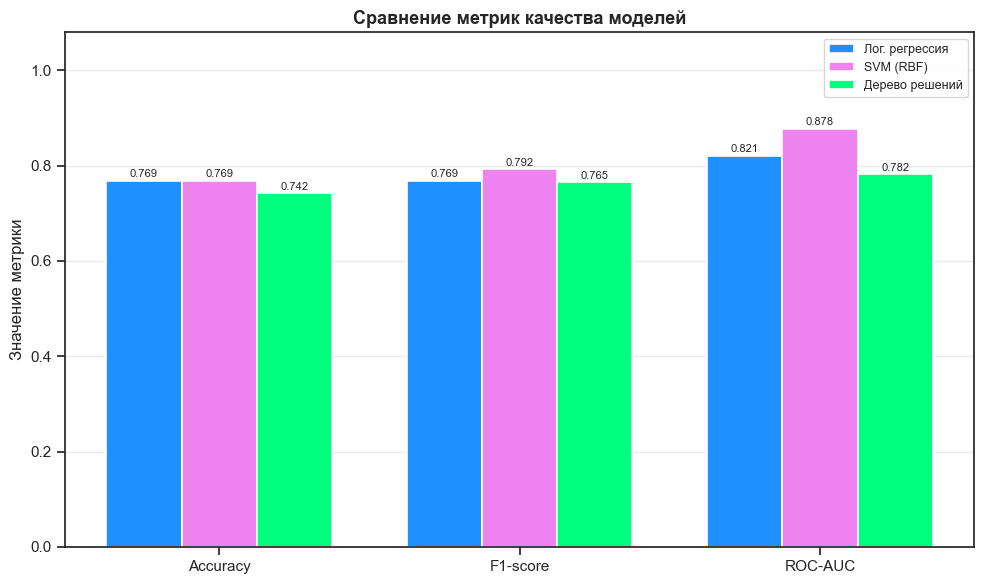

In [98]:
metrics = ['Accuracy', 'F1-score', 'ROC-AUC']
models  = ['Лог. регрессия', 'SVM (RBF)', 'Дерево решений']
values  = [
    [acc_lr,  f1_lr,  roc_lr],
    [acc_svm, f1_svm, roc_svm],
    [acc_dt,  f1_dt,  roc_dt],
]
bar_colors = ['#1E90FF', '#EE82EE', '#00FF7F']

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

for i, (model, vals, color) in enumerate(zip(models, values, bar_colors)):
    bars = plt.bar(x + i * width, vals, width, label=model,
                   color=color, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.xticks(x + width, metrics, fontsize=11)
plt.ylim(0, 1.08)
plt.ylabel('Значение метрики')
plt.title('Сравнение метрик качества моделей', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### Визуализация ROC-кривых

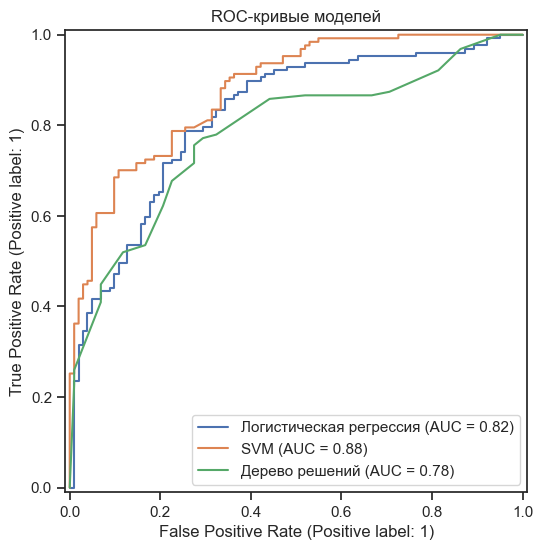

In [78]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8,6))
RocCurveDisplay.from_predictions(Y_test, Y_prob_lr, name='Логистическая регрессия', ax=ax)
RocCurveDisplay.from_predictions(Y_test, Y_prob_svm, name='SVM', ax=ax)
RocCurveDisplay.from_predictions(Y_test, Y_prob_dt, name='Дерево решений', ax=ax)
plt.title('ROC-кривые моделей')
plt.show()

### Матрицы ошибок

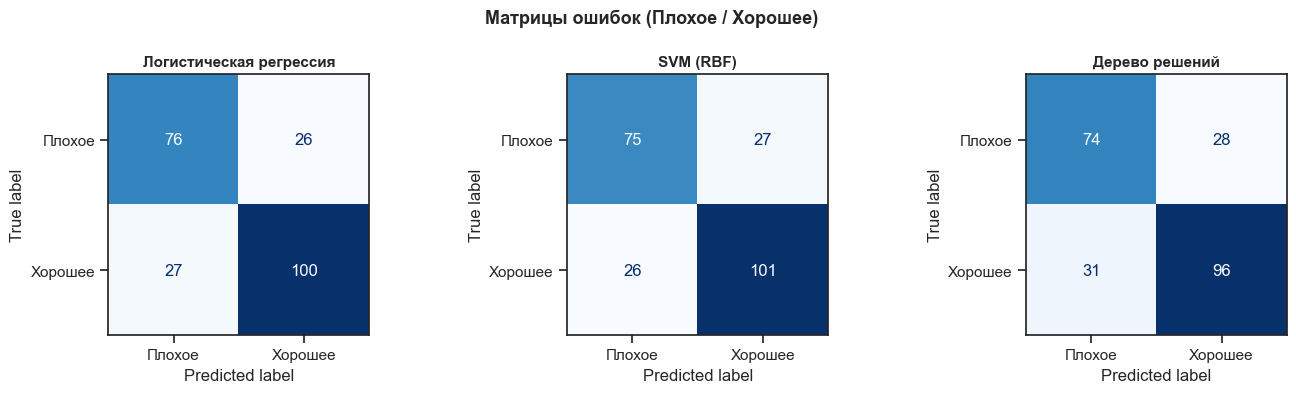

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, Y_pred) in zip(axes, [
    ('Логистическая регрессия', Y_pred_lr),
    ('SVM (RBF)',               Y_pred_svm),
    ('Дерево решений',          Y_pred_dt),
]):
    disp = ConfusionMatrixDisplay.from_predictions(
        Y_test, Y_pred,
        display_labels=['Плохое', 'Хорошее'],
        colorbar=False,
        ax=ax,
        cmap='Blues'
    )
    ax.set_title(name, fontsize=11, fontweight='bold')

fig.suptitle('Матрицы ошибок (Плохое / Хорошее)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Важность признаков в дереве решений

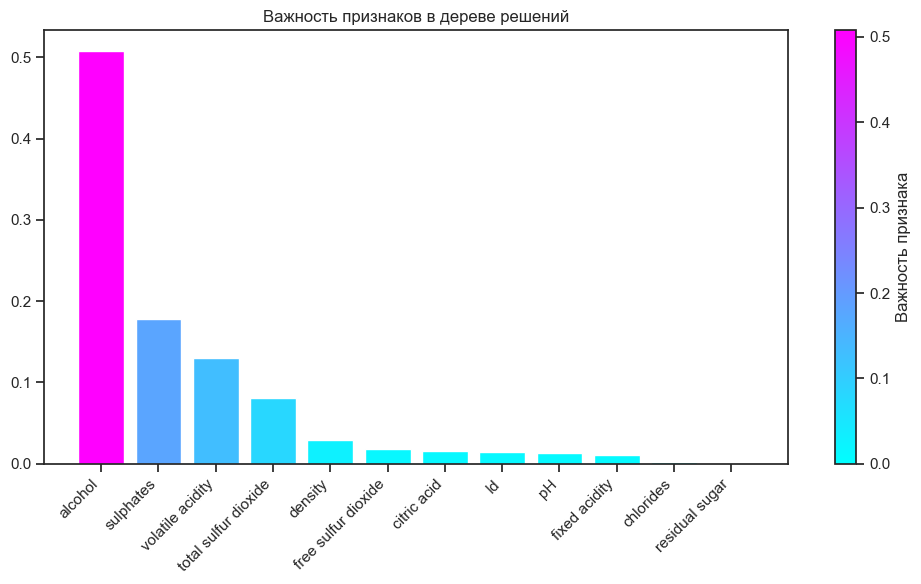

In [63]:
importances = dt.feature_importances_
features = X.columns

indices = np.argsort(importances)[::-1]
norm_vals = importances[indices] / importances[indices].max()
colors = plt.cm.cool(norm_vals)   # вместо Blues

plt.figure(figsize=(10, 6))
plt.bar(range(len(features)), importances[indices], color=colors, align='center')
plt.xticks(range(len(features)), features[indices], rotation=45, ha='right')
plt.title('Важность признаков в дереве решений')

sm = plt.cm.ScalarMappable(cmap='cool', norm=plt.Normalize(vmin=importances.min(), vmax=importances.max()))
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label='Важность признака')
plt.tight_layout()
plt.show()

## Визуализация дерева решений

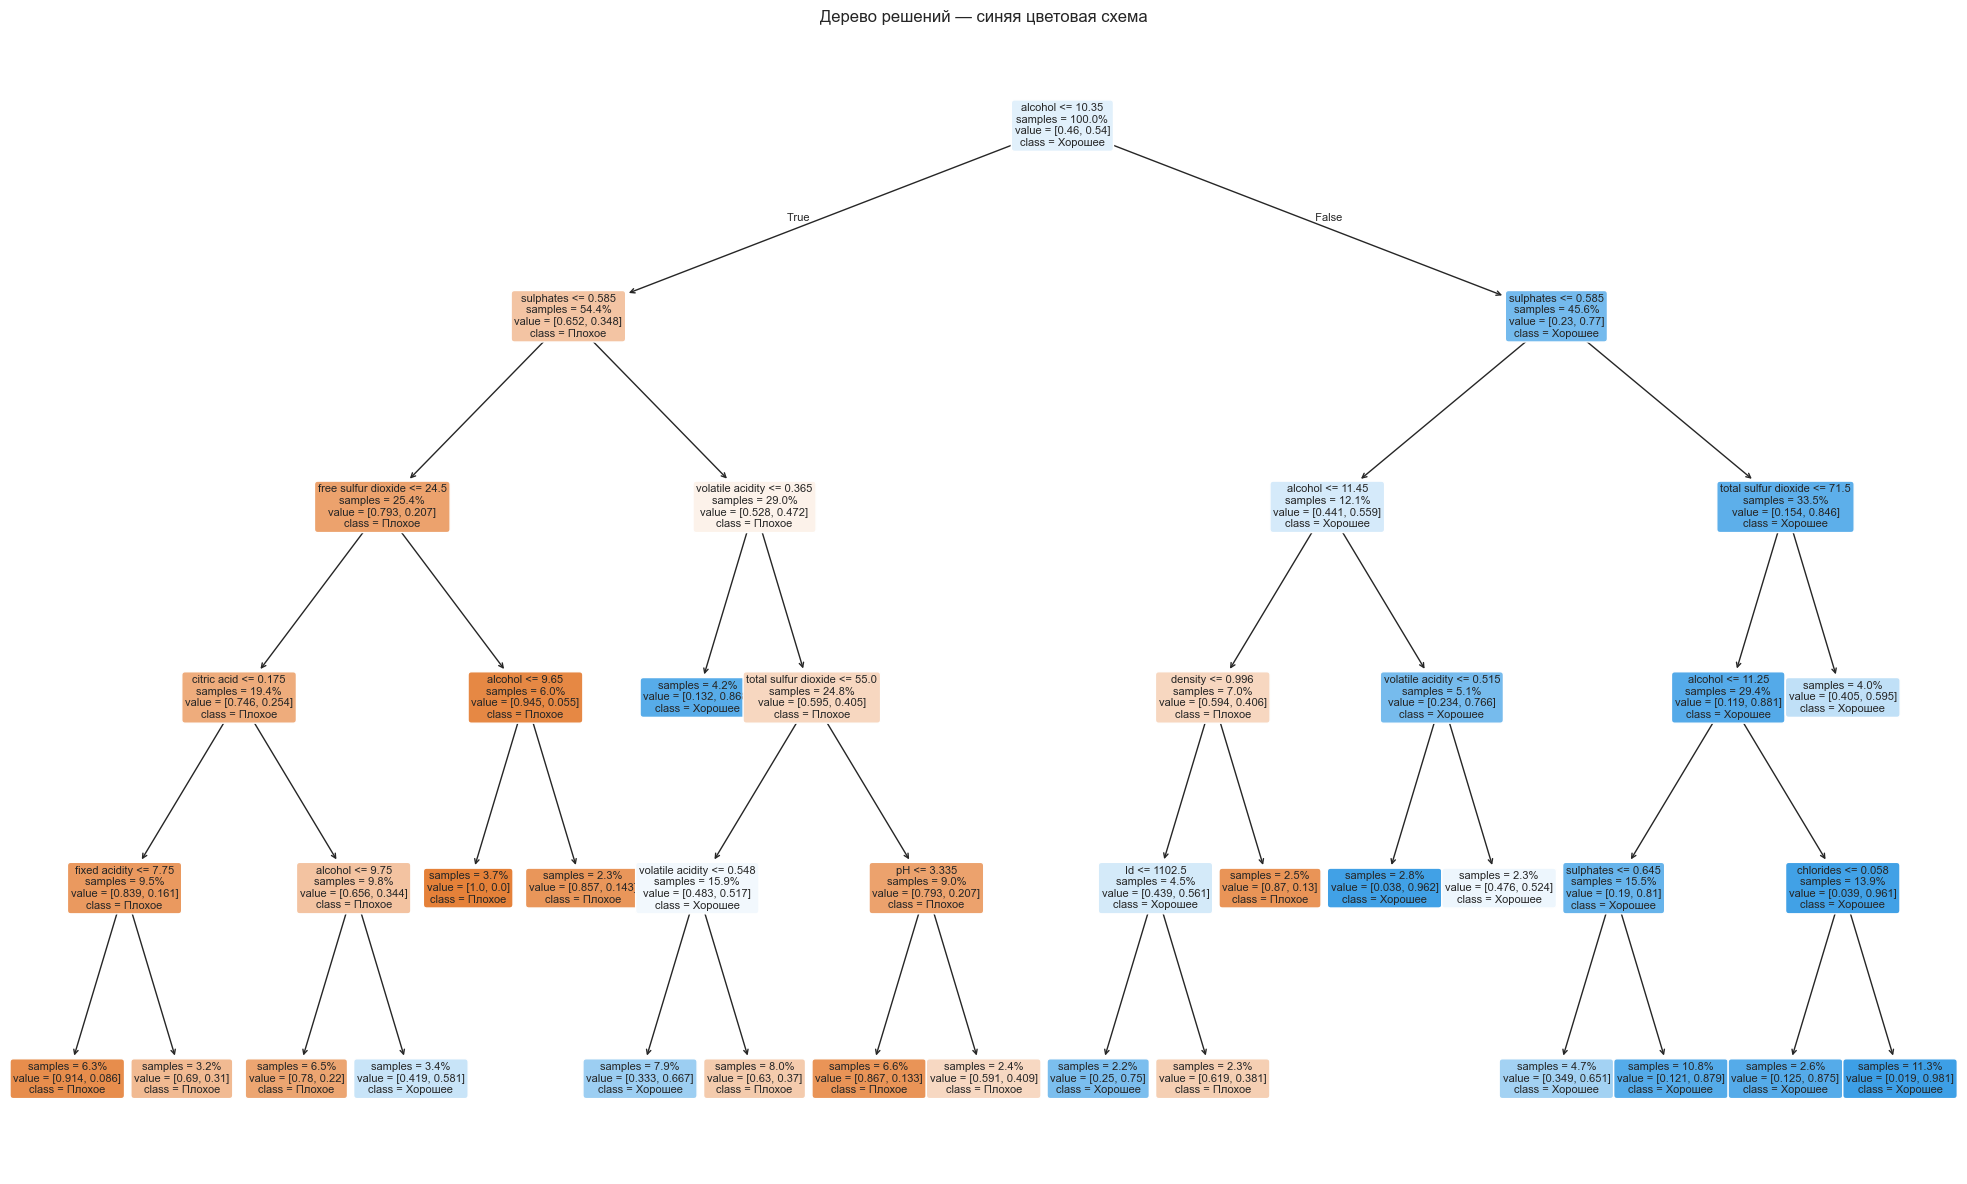

In [76]:
matplotlib.rcParams['image.cmap'] = 'Blues'

plt.figure(figsize=(20, 12))
plot_tree(dt, 
          feature_names=X.columns, 
          class_names=['Плохое', 'Хорошее'],
          filled=True,
          rounded=True,
          fontsize=8,
          impurity=False,
          proportion=True)
plt.title('Дерево решений — синяя цветовая схема')
plt.tight_layout()
plt.show()

## Правила дерева решений

In [67]:
rules = export_text(dt, feature_names=list(X.columns), max_depth=5)
print("Правила дерева решений:\n")
print(rules)

Правила дерева решений:

|--- alcohol <= 10.35
|   |--- sulphates <= 0.58
|   |   |--- free sulfur dioxide <= 24.50
|   |   |   |--- citric acid <= 0.18
|   |   |   |   |--- fixed acidity <= 7.75
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- fixed acidity >  7.75
|   |   |   |   |   |--- class: 0
|   |   |   |--- citric acid >  0.18
|   |   |   |   |--- alcohol <= 9.75
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- alcohol >  9.75
|   |   |   |   |   |--- class: 1
|   |   |--- free sulfur dioxide >  24.50
|   |   |   |--- alcohol <= 9.65
|   |   |   |   |--- class: 0
|   |   |   |--- alcohol >  9.65
|   |   |   |   |--- class: 0
|   |--- sulphates >  0.58
|   |   |--- volatile acidity <= 0.37
|   |   |   |--- class: 1
|   |   |--- volatile acidity >  0.37
|   |   |   |--- total sulfur dioxide <= 55.00
|   |   |   |   |--- volatile acidity <= 0.55
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- volatile acidity >  0.55
|   |   |   |   |   |--- class: 0
|   |   | 